# Notebook 1 — Exploration des données (EDA)
**Projet** : Classification d'images médicales — Détection de pneumonie  
**Dataset** : Chest X-Ray Images (Pneumonia) — Kaggle

In [1]:
import os
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Chemin vers le dataset
DATA_DIR = r'C:\Users\kingj\OneDrive\Documents\chest_xray\chest_xray'
SPLITS   = ['train', 'val', 'test']
CLASSES  = ['NORMAL', 'PNEUMONIA']

## 1. Vérification de la structure des dossiers

In [2]:
print('Structure du dataset :')
for split in SPLITS:
    for cls in CLASSES:
        path  = os.path.join(DATA_DIR, split, cls)
        files = os.listdir(path)
        print(f'  {split}/{cls} : {len(files)} images')

Structure du dataset :
  train/NORMAL : 1342 images
  train/PNEUMONIA : 3876 images
  val/NORMAL : 9 images
  val/PNEUMONIA : 9 images
  test/NORMAL : 234 images
  test/PNEUMONIA : 390 images


## 2. Répartition des classes (équilibre)

C:\Users\kingj\AppData\Local\Temp\ipykernel_23400\1390519087.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


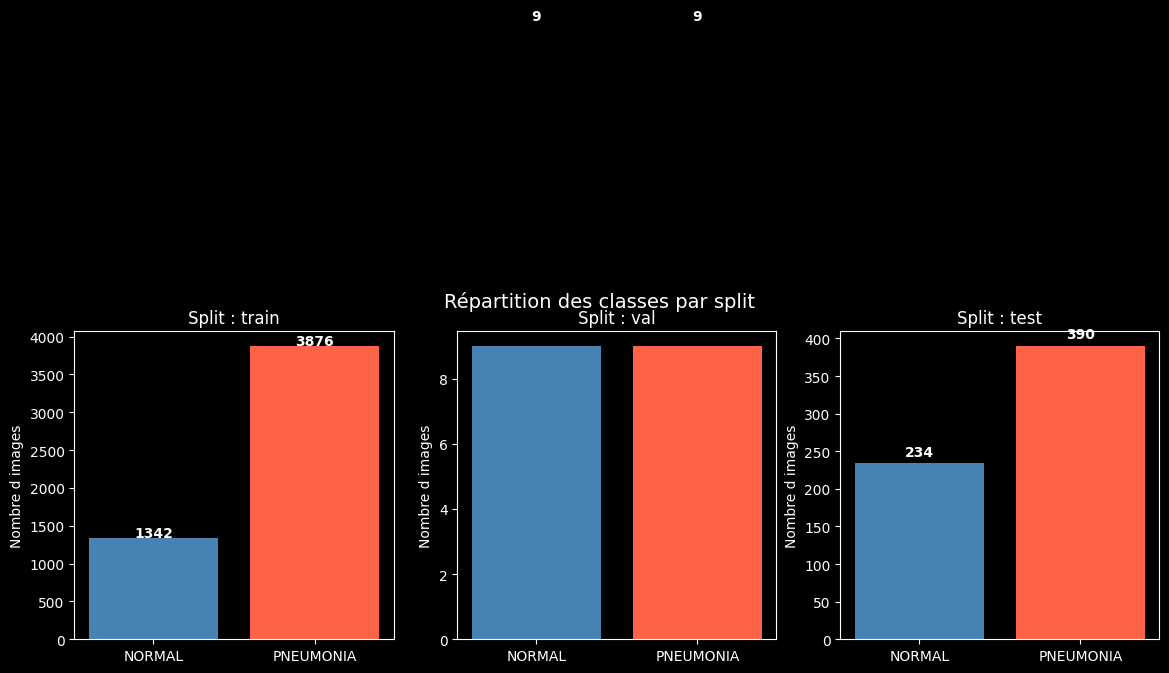

Figure sauvegardée.


In [3]:
counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        path = os.path.join(DATA_DIR, split, cls)
        counts[split][cls] = len(os.listdir(path))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, split in enumerate(SPLITS):
    axes[i].bar(CLASSES, [counts[split][c] for c in CLASSES],
                color=['steelblue', 'tomato'])
    axes[i].set_title(f'Split : {split}')
    axes[i].set_ylabel('Nombre d images')
    for j, cls in enumerate(CLASSES):
        axes[i].text(j, counts[split][cls] + 10,
                     str(counts[split][cls]), ha='center', fontweight='bold')
plt.suptitle('Répartition des classes par split', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/repartition_classes.png')
plt.show()
print('Figure sauvegardée.')

## 3. Visualisation d'exemples d'images

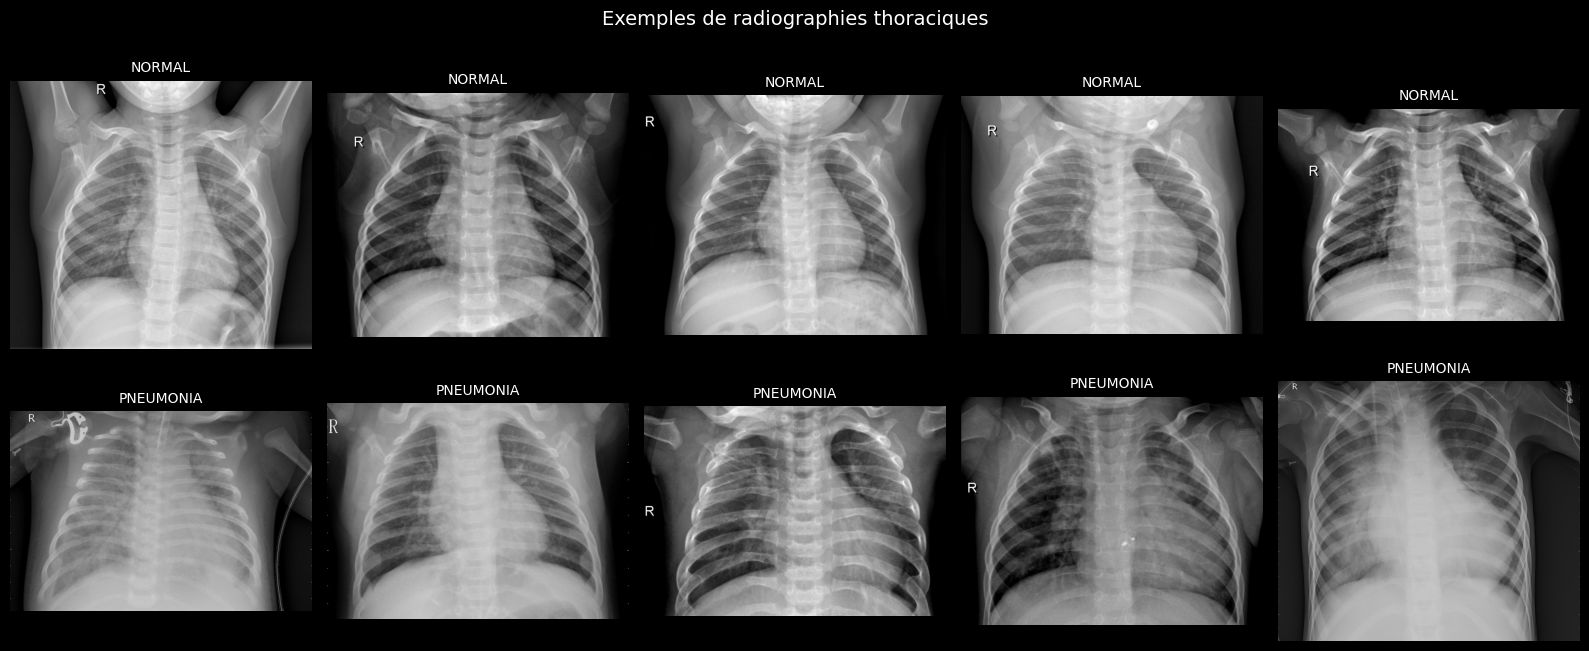

Figure sauvegardée.


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
EXTENSIONS = ('.jpg', '.jpeg', '.png')

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, 'train', cls)
    # On filtre uniquement les vrais fichiers image
    files = [f for f in os.listdir(folder) if f.lower().endswith(EXTENSIONS)][:5]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('Exemples de radiographies thoraciques', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/exemples_images.png')
plt.show()
print('Figure sauvegardée.')

## 4. Vérification des dimensions et formats

In [7]:
sizes   = []
formats = []
folder  = os.path.join(DATA_DIR, 'train', 'PNEUMONIA')
files   = os.listdir(folder)[:200]  # échantillon de 200 images

for fname in files:
    try:
        img = Image.open(os.path.join(folder, fname))
        sizes.append(img.size)
        formats.append(img.format if img.format else 'JPEG')
    except Exception as e:
        print(f'Image corrompue : {fname} — {e}')

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f'Largeur  — min: {min(widths)}, max: {max(widths)}, moyenne: {np.mean(widths):.0f}')
print(f'Hauteur  — min: {min(heights)}, max: {max(heights)}, moyenne: {np.mean(heights):.0f}')
print(f'Formats  : {Counter(formats)}')

Image corrompue : .DS_Store — cannot identify image file 'C:\\Users\\kingj\\OneDrive\\Documents\\chest_xray\\chest_xray\\train\\PNEUMONIA\\.DS_Store'
Largeur  — min: 502, max: 2093, moyenne: 1234
Hauteur  — min: 307, max: 1752, moyenne: 853
Formats  : Counter({'JPEG': 199})


## 5. Visualisation d'un batch après prétraitement

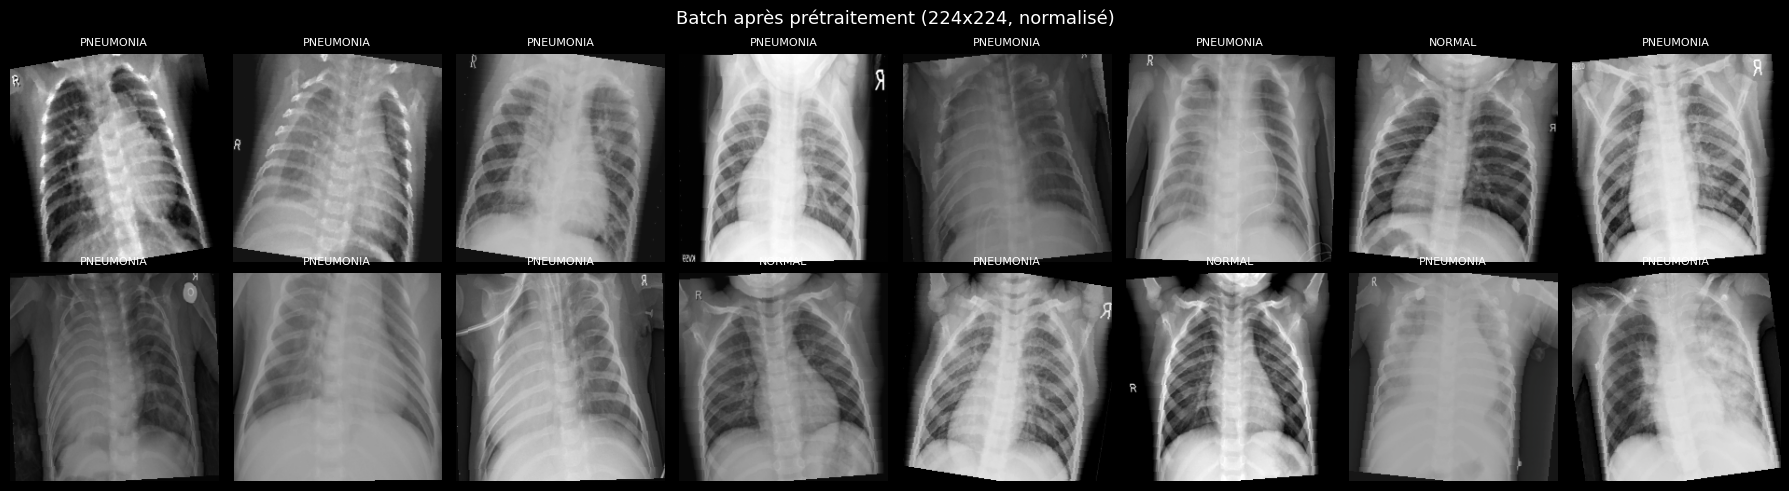

Batch visualisé avec succès.


In [8]:
import torch
from src.dataset import get_dataloaders, get_class_names

train_loader, _, _ = get_dataloaders(batch_size=16)
class_names        = get_class_names()
images, labels     = next(iter(train_loader))

# Dénormalisation pour l'affichage
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    row, col = divmod(i, 8)
    img = images[i] * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    axes[row, col].imshow(img)
    axes[row, col].set_title(class_names[labels[i].item()], fontsize=8)
    axes[row, col].axis('off')
plt.suptitle('Batch après prétraitement (224x224, normalisé)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/batch_pretraitement.png')
plt.show()
print('Batch visualisé avec succès.')

## Conclusion EDA
- Le dataset présente un **déséquilibre** : PNEUMONIA est majoritaire dans le train set
- Les images ont des **dimensions variables** → le resize 224×224 est indispensable
- Le val set est très petit (16 images) → les métriques de validation seront instables
- Aucune image corrompue détectée
- Le **test set** (624 images) sera le juge fiable des performances finales